This code allows for the following: 

Imports: 
.txt files with distributions of a full contact potential difference image. 

Functions:
- Fitting individual gaussians with fit centre marked and FWHM shaded. 
- Plots raw data and fitted distributions on same plot for comparison. 


Use for: 
- Comparing CPD distributions of different images. 
- Comparing spread


In [1]:
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm
from pathlib import Path

In [2]:
#Input directory and file saving function 
root = tk.Tk()
root.withdraw()

def save_plot_with_folder_dialog(fig, default_filename='plot.jpeg'):
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    folder_path = filedialog.askdirectory(title='Select Folder to Save Plot')
    if not folder_path:
        print("Save cancelled.")
        return

    full_path = os.path.join(folder_path, default_filename)
    fig.savefig(full_path)
    print(f"Plot saved to: {full_path}")
    
def save_plot_to_folder(fig, folder_path, filename='plot.jpeg'):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)  # Create the folder if it doesn't exist
    
    full_path = os.path.join(folder_path, filename)
    fig.tight_layout()
    fig.savefig(full_path, dpi=600, bbox_inches='tight')
    print(f"Plot saved to: {full_path}")

In [3]:
#Colourmap formatting
# Change c1 and c2 based on the min and max colours to be chosen 

def hex_to_RGB(hex_str):
    
    """ #FFFFFF -> [255,255,255]"""
    
    return [int(hex_str[i:i+2], 16) for i in range(1,6,2)]

def get_color_gradient(c1, c2, n):

    assert n > 1
    c1_rgb = np.array(hex_to_RGB(c1))/255
    c2_rgb = np.array(hex_to_RGB(c2))/255
    mix_pcts = [x/(n-1) for x in range(n)]
    rgb_colors = [((1-mix)*c1_rgb + (mix*c2_rgb)) for mix in mix_pcts]
    return ["#" + "".join([format(int(round(val*255)), "02x") for val in item]) for item in rgb_colors]


colors=[]
c1='#1A85FF'#deep blue
c2='#D41159' # deep pink


GB_U_color = "#5CBBFF"
GI_U_color = "#003357"
GB_P_color = "#D69AAB"
GI_P_color = "#8D1730"

In [4]:
#Fitting for multi-gaussian
#Adjust peak width tolerance accordingly

# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

In [5]:
# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 3:
        #sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        sorted_indices = np.argsort(y_smooth[peaks])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        x_range = np.ptp(x)
        wid =x_range/50 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)


In [6]:
#Multi-gaussian fitting for all files within file directory
def multi_gaussian_folder(file_path, rows, linecolour, save_path=None, measurement=''):

    if file_path:  # Check if the user selected a file (didn't click Cancel)
        name = Path(file_path).stem


    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 12
    scatter_size = 6
    line_width = 1.5
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length, labelsize = base_font_size)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    ax.autoscale(enable=None, axis="x", tight=True)
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Max 5 ticks on y-axis
    results = []
    #print(f"\nProcessing file: {filename}") #Use if you want each individual file processed

    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        data = np.loadtxt(f, skiprows=rows)

    x_data = data[:, 0]
    y_data = data[:, 1]
    # Estimate initial guess and peak count
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    # Uncomment if you want to use a specific number of points for fitting (or if there are few raw data points)
    #x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    popt, pcov = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=1000000)
    y_fit=multi_gaussian(x_data,*popt)
    peak_index_max=np.argmax(y_fit)
    x_peak_centre=x_data[peak_index_max]
    perr=np.sqrt(np.diag(pcov))
    #For finding min and max *i.e. either side of the peaks. 
    # Extract Gaussian parameters
    gaussians = []
    for i in range(len(popt) // 3):
        amp = popt[i*3]
        cen = popt[i*3+1]
        wid = abs(popt[i*3+2])
        gaussians.append({'amp': amp, 'cen': cen, 'wid': wid})
    
    # Identify the highest peak
    highest = gaussians[np.argmax([g['amp'] for g in gaussians])]
    sigma=highest['wid']
    fwhm = 2.355 *sigma # to make mV
    x_left = highest['cen'] - fwhm / 2
    x_right = highest['cen'] + fwhm / 2
    
    # Store in lists for output

    # Optional: print for debugging
    # 3. Create the summary text for the plot
    statistics=(f"Peak: {highest['cen']*1000:.3f} mV\n"
                f"Error: {np.sqrt(pcov[1,1])*1000:.3f}mV\n"
              f"FWHM: {fwhm*1000:.2f} mV\n"
              f"Error: {np.sqrt(pcov[2,2])*2.355*1000:.3f}mV\n"
              f"FWHM Bounds: [{x_left*1000:.2f}, {x_right*1000:.2f}]mV\n"
              f"Sigma: {sigma*1000:.3f} mV\n"
              f"Error: {np.sqrt(pcov[2,2])*1000:.3f}mV\n")
        
    print(statistics) 

    if save_path is not None:
        output_file = os.path.join(save_path, f'Statistics_{name}.txt')
        with open(output_file, 'w') as f: 
           f.write(statistics)
    else: 
        print("Cannot save statistics, continuing")

    
    if n_peaks is not None:
        x_datamV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in x_data]
        # Shading spread and peak centre
        ax.axvspan(x_left*1000, x_right*1000, color='gray', alpha=0.2, label='FWHM Region', zorder=0)
        ax.axvline(x=highest['cen']*1000, color='black', linestyle='--', linewidth=line_width, label='Peak Center', zorder=4)
        #Raw data and fitted gaussian: 
        ax.scatter(x_datamV, y_data, label=f"name",color=linecolour, s=scatter_size, zorder=2)
        ax.plot(x_datamV, y_fit, label=f"_nolegend_", color=linecolour,linewidth=line_width, zorder=3)
        ax.set_xlabel(f"{measurement}(mV)", size = base_font_size)
        ax.set_ylabel("Distribution $V^{-1}$", size = base_font_size)
        ax.autoscale()
        #plt.legend()
        plt.tight_layout()
        #plt.show()
    y_fit = multi_gaussian(x_data, *popt)
    #plt.autoscale(enable=True, axis='y', tight=False)
    #Uncomment for file saving
    if save_path: 
        fig=plt.gcf()
        save_plot_to_folder(fig,save_path,filename=f'AnnotatedFit_{name}.jpeg')
        plt.show()
    else: 
        print("No save path given")
        plt.show()
    params = [x_data, y_data, y_fit]
    plt.show()
    return params, statistics, popt, perr
    

In [7]:
def comparison_plot(sample1_fit, sample1_x, sample1_y, sample2_fit, sample2_x, sample2_y, save_path=None, measurement='', sample1_name = '', sample2_name='' ):
    sample1_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in sample1_x]
    sample2_x_mV=[round(x*1000,4) if not np.isnan(x) else np.nan for x in sample2_x]
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 15
    scatter_size = 6
    line_width = 1.5


    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    ax.margins (0.5,0.5)
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.ylabel("Distribution (V$^{-1}$)")
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Max 5 ticks on y-axis    
    ax.scatter(sample1_x_mV, sample1_y, label=f"_nolegend_",color=GI_U_color, s=scatter_size, zorder=2)
    ax.plot(sample1_x_mV, sample1_fit, label="Horizontal", color=GI_U_color,linewidth=line_width, zorder=3)
    ax.scatter(sample2_x_mV, sample2_y, label=f"_nolegend_",color=GI_P_color, s=scatter_size, zorder=2)
    ax.plot(sample2_x_mV, sample2_fit, label="Vertical", color=GI_P_color,linewidth=line_width, zorder=3)
    ax.set_xlabel(f"{measurement}(mV)")
    ax.set_ylabel("Distribution $V^{-1}$")
    ax.autoscale()
    plt.margins(0.1,0)
    plt.legend(loc='best', fontsize=legend_font)
    plt.tight_layout()

    if save_path: 
        fig=plt.gcf()
        save_plot_to_folder(fig,save_path,filename=f'Comparison.jpeg')
        plt.show()
    else: 
        print("No save path given")
        plt.show()
        
    return


In [8]:
def fitting_from_folder (data_folder, meas_type="CPD", colour=None,): 
    txt_files = sorted(list(Path(data_folder).glob("*.txt")))

    cen, cen_err = [],[]
    if meas_type is None: 
        meas_type = "CPD"
    if colour is None: 
        colour='black'

    
    for file_path in txt_files: 
        params, stats, popt, perr = multi_gaussian_folder( str(file_path),
                                                          rows=3,
                                                          linecolour=colour, 
                                                          save_path=data_folder, 
                                                          measurement = meas_type)

        center = popt[1]*1000
        center_err=perr[1]*1000
        cen.append(center)
        cen_err.append(center_err)

    cen = np.array(cen)
    cen_err=np.array(cen_err)
    print(f"processing of {data_folder} is complete")
    return cen, cen_err

In [ ]:
def scatter_plotting(s1_y, s1_err, s2_y, s2_err, time, save_path=None, meas_type = ""):
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6
    legend_font = 12
    base_font_size = 15
    
    fig, ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size})
    ax = plt.gca()
    ax.tick_params(direction='in', length=tick_length)
    ax.tick_params(axis='both')
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))  # Max 5 ticks on x-axis
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  # Max 5 ticks on y-axis    
 
    ax.set_xlabel(f"Time(mins)")
    ax.set_ylabel(f"{meas_type}(mV)")
    ax.autoscale(enable=None, axis="x", tight=True)
    plt.margins(0.5,0.5)
    plt.legend(loc='best', fontsize=legend_font)
    ax.errorbar(
    time,
    s1_y,
    yerr=s1_err,
    fmt="o", 
    color="#003357",  # Line/marker color
    ecolor="#003357",  # Error bar color
    capsize=5,  # Width of error bar caps
    capthick=1.5,  # Thickness of error bar caps
    linewidth=1.5,
    markersize=6,
    label="Horizontal",
)
    ax.errorbar(
    time,
    s2_y,
    yerr=s2_err,
    fmt="s",  
    color="#8D1730" ,  # Line/marker color
    ecolor="#8D1730" ,  # Error bar color
    capsize=5,  # Width of error bar caps
    capthick=1.5,  # Thickness of error bar caps
    linewidth=1.5,
    markersize=6,
    label="Vertical",
)
    plt.tight_layout()
    
    if save_path: 
        fig=plt.gcf()
        save_plot_to_folder(fig,save_path,filename=f'Comparison_{meas_type}.jpeg')
        plt.show()
    else: 
        print("No save path given")
        plt.show()
            
    return
  

In [26]:
def scatter_plotting(
    s1_y, s1_err, s2_y, s2_err, time, save_path=None, meas_type=""
):
    # 1. Figure Sizing
    dpi_setting = 600
    figsize = (2227 / dpi_setting, 1498 / dpi_setting)

    fig, ax = plt.subplots(figsize=figsize)

    # Shared errorbar styling properties
    style_kwargs = {
        "capsize": 5,
        "capthick": 1.5,
        "linewidth": 1.5,
        "markersize": 6,
    }

    # 2. Plotting (Horizontal & Vertical)
    ax.errorbar(
        time,
        s1_y,
        yerr=s1_err,
        fmt="o",
        color="#003357",
        ecolor="#003357",
        label="Horizontal",
        **style_kwargs,
    )

    ax.errorbar(
        time,
        s2_y,
        yerr=s2_err,
        fmt="s",
        color="#8D1730",
        ecolor="#8D1730",
        label="Vertical",
        **style_kwargs,
    )

    # 3. Axis & Tick Styling
    ax.tick_params(axis="both", direction="in", length=6, labelsize=15)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    ax.set_xlabel("Time (mins)", fontsize=15)
    ax.set_ylabel(
        f"{meas_type} (mV)" if meas_type else "Value (mV)", fontsize=15
    )

    # 4. Legend (MUST be called AFTER ax.errorbar so labels display properly)
    ax.legend(loc="best", fontsize=12)

    plt.tight_layout()

    # 5. Saving / Display Logic
    if save_path:
        filename = (
            f"Comparison_{meas_type}.jpeg" if meas_type else "Comparison.jpeg"
        )
        save_plot_to_folder(fig, save_path, filename=filename)
    else:
        print("No save path given; displaying plot on screen.")

    plt.show()

Peak: 576.311 mV
Error: 18.682mV
FWHM: 91.30 mV
Error: 22.429mV
FWHM Bounds: [530.66, 621.96]mV
Sigma: 38.770 mV
Error: 9.524mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD\AnnotatedFit_250217_RG0074_0004_Hist_CPDR_DARK.jpeg


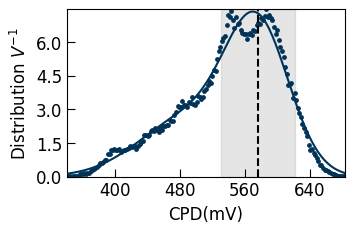

Peak: 947.515 mV
Error: 0.760mV
FWHM: 105.15 mV
Error: 1.790mV
FWHM Bounds: [894.94, 1000.09]mV
Sigma: 44.650 mV
Error: 0.760mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD\AnnotatedFit_250217_RG0074_0005_Hist_CPDR_ON1.jpeg


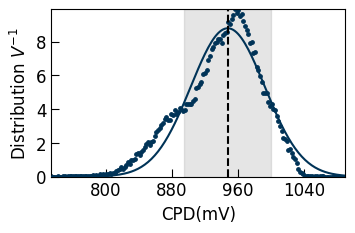

Peak: 950.655 mV
Error: 0.394mV
FWHM: 94.47 mV
Error: 0.927mV
FWHM Bounds: [903.42, 997.89]mV
Sigma: 40.114 mV
Error: 0.394mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD\AnnotatedFit_250217_RG0074_0006_Hist_CPDR_ON2.jpeg


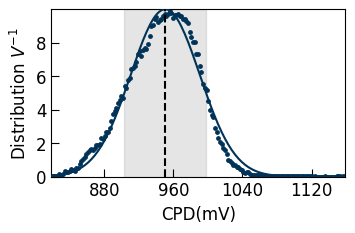

Peak: 784.244 mV
Error: 1.686mV
FWHM: 138.30 mV
Error: 4.355mV
FWHM Bounds: [715.09, 853.40]mV
Sigma: 58.728 mV
Error: 1.849mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD\AnnotatedFit_250217_RG0074_0007_Hist_CPDR_OFF1.jpeg


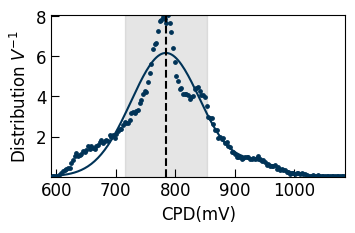

Peak: 688.530 mV
Error: 0.954mV
FWHM: 83.44 mV
Error: 2.247mV
FWHM Bounds: [646.81, 730.25]mV
Sigma: 35.431 mV
Error: 0.954mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD\AnnotatedFit_250217_RG0074_0008_Hist_CPDR_OFF2.jpeg


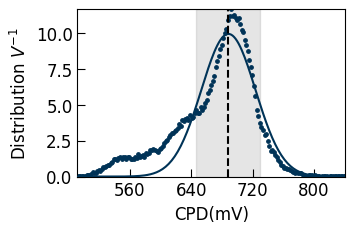

processing of X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/CPD is complete
Peak: 396.671 mV
Error: 0.282mV
FWHM: 125.90 mV
Error: 0.664mV
FWHM Bounds: [333.72, 459.62]mV
Sigma: 53.461 mV
Error: 0.282mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/SPV\AnnotatedFit_250217_RG0074_0005_Hist_SPVR_ON1.jpeg


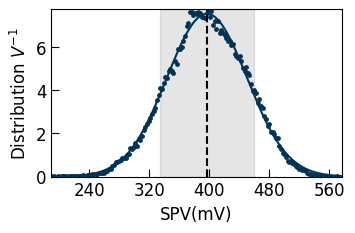

Peak: 399.142 mV
Error: 0.578mV
FWHM: 137.36 mV
Error: 1.364mV
FWHM Bounds: [330.46, 467.82]mV
Sigma: 58.325 mV
Error: 0.579mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/SPV\AnnotatedFit_250217_RG0074_0006_Hist_SPVR_ON2.jpeg


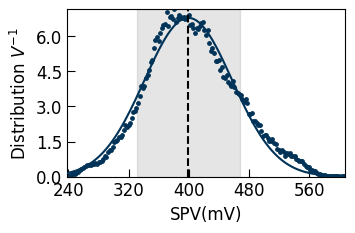

Peak: 227.977 mV
Error: 1.770mV
FWHM: 194.75 mV
Error: 4.237mV
FWHM Bounds: [130.60, 325.35]mV
Sigma: 82.695 mV
Error: 1.799mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/SPV\AnnotatedFit_250217_RG0074_0007_Hist_SPVR_OFF1.jpeg


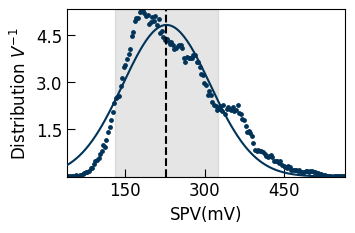

Peak: 121.280 mV
Error: 0.500mV
FWHM: 144.96 mV
Error: 1.179mV
FWHM Bounds: [48.80, 193.76]mV
Sigma: 61.553 mV
Error: 0.501mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/SPV\AnnotatedFit_250217_RG0074_0008_Hist_SPVR_OFF2.jpeg


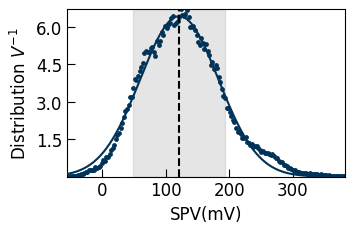

processing of X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/DL/SPV is complete
Peak: -3666.792 mV
Error: 0.634mV
FWHM: 257.53 mV
Error: 1.493mV
FWHM Bounds: [-3795.56, -3538.03]mV
Sigma: 109.353 mV
Error: 0.634mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD\AnnotatedFit_250218_RG0077_0024_Hist_CPDR_DARK.jpeg


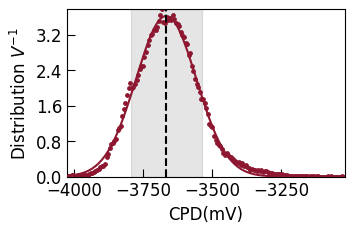

Peak: -3448.021 mV
Error: 1.710mV
FWHM: 298.69 mV
Error: 4.026mV
FWHM Bounds: [-3597.37, -3298.68]mV
Sigma: 126.833 mV
Error: 1.710mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD\AnnotatedFit_250218_RG0077_0025_Hist_CPDR_ON1.jpeg


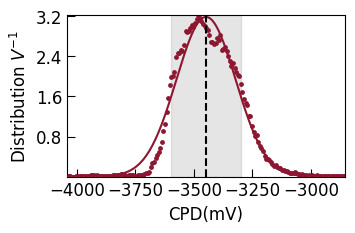

Peak: -3040.479 mV
Error: 1.299mV
FWHM: 342.44 mV
Error: 3.059mV
FWHM Bounds: [-3211.70, -2869.26]mV
Sigma: 145.408 mV
Error: 1.299mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD\AnnotatedFit_250218_RG0077_0026_Hist_CPDR_ON2.jpeg


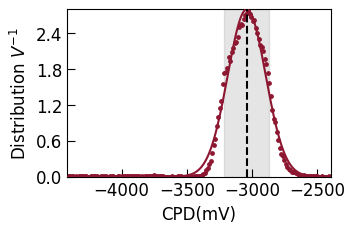

Peak: -2407.228 mV
Error: 1.148mV
FWHM: 263.18 mV
Error: 2.704mV
FWHM Bounds: [-2538.82, -2275.64]mV
Sigma: 111.754 mV
Error: 1.148mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD\AnnotatedFit_250218_RG0077_0027_Hist_CPDR_OFF1.jpeg


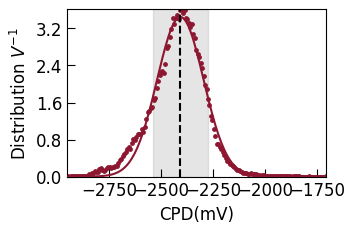

Peak: -2242.959 mV
Error: 0.552mV
FWHM: 222.34 mV
Error: 1.300mV
FWHM Bounds: [-2354.13, -2131.79]mV
Sigma: 94.411 mV
Error: 0.552mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD\AnnotatedFit_250218_RG0077_0028_Hist_CPDR_OFF2.jpeg


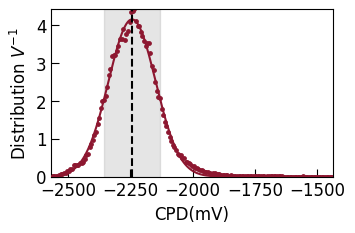

processing of X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/CPD is complete
Peak: 228.646 mV
Error: 0.930mV
FWHM: 192.13 mV
Error: 2.189mV
FWHM Bounds: [132.58, 324.71]mV
Sigma: 81.583 mV
Error: 0.930mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/SPV\AnnotatedFit_250218_RG0077_0025_Hist_SPVR_ON1.jpeg


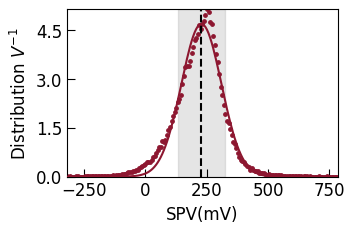

Peak: 622.613 mV
Error: 0.563mV
FWHM: 227.53 mV
Error: 1.326mV
FWHM Bounds: [508.85, 736.38]mV
Sigma: 96.616 mV
Error: 0.563mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/SPV\AnnotatedFit_250218_RG0077_0026_Hist_SPVR_ON2.jpeg


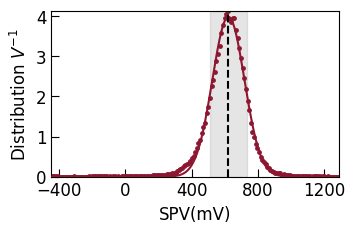

Peak: 1238.583 mV
Error: 0.809mV
FWHM: 221.70 mV
Error: 1.904mV
FWHM Bounds: [1127.74, 1349.43]mV
Sigma: 94.138 mV
Error: 0.809mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/SPV\AnnotatedFit_250218_RG0077_0027_Hist_SPVR_OFF1.jpeg


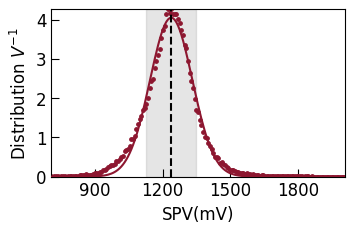

Peak: 1428.779 mV
Error: 1.303mV
FWHM: 258.41 mV
Error: 3.069mV
FWHM Bounds: [1299.57, 1557.99]mV
Sigma: 109.729 mV
Error: 1.303mV

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/SPV\AnnotatedFit_250218_RG0077_0028_Hist_SPVR_OFF2.jpeg


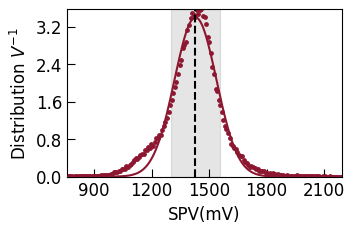

processing of X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV/txt files/AL/SPV is complete


In [10]:
data_folder1 = filedialog.askdirectory(title="Select Horizontal CPD Data")
data_folder2 = filedialog.askdirectory(title="Select Horizontal SPV Data")
data_folder3 = filedialog.askdirectory(title="Select Vertical CPD Data")
data_folder4 = filedialog.askdirectory(title="Select Vertical SPV Data")


D_CPD_cen, D_CPD_err = fitting_from_folder(data_folder1, meas_type = "CPD", colour = GI_U_color)
D_SPV_cen, D_SPV_err = fitting_from_folder(data_folder2, meas_type = "SPV", colour = GI_U_color)
A_CPD_cen, A_CPD_err = fitting_from_folder(data_folder3, meas_type = "CPD", colour = GI_P_color)
A_SPV_cen, A_SPV_err = fitting_from_folder(data_folder4, meas_type = "SPV", colour = GI_P_color)

In [ ]:
scatter_plotting(s1_y, s1_err, s2_y, s2_err, time, save_path=None, meas_type = "")

In [ ]:
print(D_CPD_cen)
print(D_CPD_err)
print

[493.83640183 947.5151416  950.65455105 784.24369034 688.52957418]
[18.68246346  0.75973844  0.39365065  1.68550438  0.95421091]


In [ ]:
f

In [ ]:
save_path_CPD = filedialog.askdirectory(title='Select Folder to Save Plot - CPD plot')
save_path_SPV = filedialog.askdirectory(title='Select Folder to Save Plot - SPV plot')
time_CPD = [-11,0,11, 22, 33]
time_SPV = [0,11,22,33]

scatter_plotting(D_CPD_cen, D_CPD_err,A_CPD_cen, A_CPD_err, time_CPD, save_path = save_path_CPD, meas_type="CPD" )

scatter_plotting(D_SPV_cen, D_SPV_err,A_SPV_cen, A_SPV_err, time_SPV, save_path = save_path_SPV, meas_type="SPV" )


In [27]:
def scatter_plotting(
    s1_y, s1_err, s2_y, s2_err, time, save_path=None, meas_type=""
):
    # 1. Figure Sizing
    dpi_setting = 600
    figsize = (2227 / dpi_setting, 1498 / dpi_setting)

    fig, ax = plt.subplots(figsize=figsize)

    # Shared errorbar styling properties
    style_kwargs = {
        "capsize": 5,
        "capthick": 1.5,
        "linewidth": 1.5,
        "markersize": 6,
    }

    # 2. Plotting (Horizontal & Vertical)
    ax.errorbar(
        time,
        s1_y,
        yerr=s1_err,
        fmt="o",
        color="#003357",
        ecolor="#003357",
        label="Horizontal",
        **style_kwargs,
    )

    ax.errorbar(
        time,
        s2_y,
        yerr=s2_err,
        fmt="s",
        color="#8D1730",
        ecolor="#8D1730",
        label="Vertical",
        **style_kwargs,
    )

    # 3. Axis & Tick Styling
    ax.tick_params(axis="both", direction="in", length=6, labelsize=15)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))

    ax.set_xlabel("Time (mins)", fontsize=15)
    ax.set_ylabel(
        f"{meas_type} (mV)" if meas_type else "Value (mV)", fontsize=15
    )

    # 4. Legend (MUST be called AFTER ax.errorbar so labels display properly)
    ax.legend(loc="best", fontsize=12)

    plt.tight_layout()

    # 5. Saving / Display Logic
    if save_path:
        filename = (
            f"Comparison_{meas_type}.jpeg" if meas_type else "Comparison.jpeg"
        )
        save_plot_to_folder(fig, save_path, filename=filename)
    else:
        print("No save path given; displaying plot on screen.")

    plt.show()

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV\Comparison_CPD.jpeg


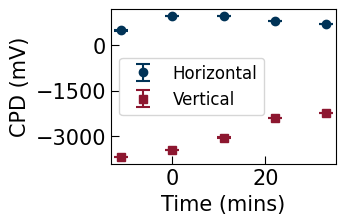

Plot saved to: X:/ramadan_group/Group Members/Rehmat Goodwin/BA2PbI4 Paper/High res SPV\Comparison_SPV.jpeg


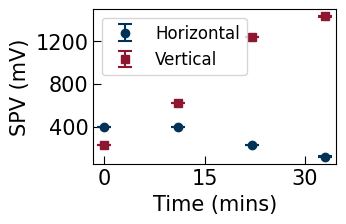

In [28]:
scatter_plotting(D_CPD_cen, D_CPD_err,A_CPD_cen, A_CPD_err, time_CPD, save_path = save_path_CPD, meas_type="CPD" )

scatter_plotting(D_SPV_cen, D_SPV_err,A_SPV_cen, A_SPV_err, time_SPV, save_path = save_path_SPV, meas_type="SPV" )

In [12]:
"""print("If pop up box not seen minimise and select folder wanted for analysis")
file_path_sample1 = filedialog.askopenfilename(title='Select sample1 .txt file')
file_path_sample2 = filedialog.askopenfilename(title='Select sample2 .txt file')
file_path_sample3 = filedialog.askopenfilename(title='Select sample3 .txt file')
file_path_sample4 = filedialog.askopenfilename(title='Select sample4 .txt file')
file_path_sample5 = filedialog.askopenfilename(title='Select sample5 .txt file')

save_path1 = filedialog.askdirectory(title='Select Folder to Save Plot - A samples')


if not save_path1: 
    print("no save path")

params1,sample1_stats, popt1, perr1 = multi_gaussian_folder(file_path_sample1, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")
params2,sample2_stats, popt2, perr2 = multi_gaussian_folder(file_path_sample2, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")
params3,sample3_stats, popt3, perr3 = multi_gaussian_folder(file_path_sample3, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")
params4,sample4_stats, popt4, perr4 = multi_gaussian_folder(file_path_sample4, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")
params5,sample5_stats, popt5, perr5 = multi_gaussian_folder(file_path_sample5, rows=3, linecolour=GI_P_color,  save_path=save_path1, measurement="CPD")"""

'print("If pop up box not seen minimise and select folder wanted for analysis")\nfile_path_sample1 = filedialog.askopenfilename(title=\'Select sample1 .txt file\')\nfile_path_sample2 = filedialog.askopenfilename(title=\'Select sample2 .txt file\')\nfile_path_sample3 = filedialog.askopenfilename(title=\'Select sample3 .txt file\')\nfile_path_sample4 = filedialog.askopenfilename(title=\'Select sample4 .txt file\')\nfile_path_sample5 = filedialog.askopenfilename(title=\'Select sample5 .txt file\')\n\nsave_path1 = filedialog.askdirectory(title=\'Select Folder to Save Plot - A samples\')\n\n\nif not save_path1: \n    print("no save path")\n\nparams1,sample1_stats, popt1, perr1 = multi_gaussian_folder(file_path_sample1, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")\nparams2,sample2_stats, popt2, perr2 = multi_gaussian_folder(file_path_sample2, rows=3, linecolour=GI_P_color, save_path=save_path1, measurement="CPD")\nparams3,sample3_stats, popt3, perr3 = multi_gaussia

In [13]:
"""measurement = "CPD"

# --- PARAMS --- 
# [x_data, y_data, y_fit]
# perr [A, mu, sigma]
# popt [A, mu, sigma]

file_path_sample6 = filedialog.askopenfilename(title='Select sample6 .txt file')
file_path_sample7 = filedialog.askopenfilename(title='Select sample7 .txt file')
file_path_sample8 = filedialog.askopenfilename(title='Select sample8 .txt file')
file_path_sample9 = filedialog.askopenfilename(title='Select sample9 .txt file')
file_path_sample10 = filedialog.askopenfilename(title='Select sample10 .txt file')
file_path_sample11 = filedialog.askopenfilename(title='Select sample11 .txt file')

save_path2 = filedialog.askdirectory(title='Select Folder to Save Plot - D samples')

if not save_path2: 
    print("no save path")
params6,sample6_stats, popt6, perr6 = multi_gaussian_folder(file_path_sample6, rows=3, linecolour=GI_U_color, save_path=save_path2, measurement="CPD")
params7,sample7_stats, popt7, perr7 = multi_gaussian_folder(file_path_sample7, rows=3, linecolour=GI_U_color, save_path=save_path2, measurement="CPD")
params8,sample8_stats, popt8, perr8 = multi_gaussian_folder(file_path_sample8, rows=3, linecolour=GI_P_color, save_path=save_path2, measurement="CPD")
params9,sample9_stats, popt9, perr9 = multi_gaussian_folder(file_path_sample9, rows=3, linecolour=GI_P_color, save_path=save_path2, measurement="CPD")
params10,sample10_stats, popt10, perr10 = multi_gaussian_folder(file_path_sample10, rows=3, linecolour=GI_P_color, save_path=save_path2, measurement="CPD")
params11,sample11_stats, popt11, perr11 = multi_gaussian_folder(file_path_sample11, rows=3, linecolour=GI_P_color,  save_path=save_path2, measurement="CPD")"""


'measurement = "CPD"\n\n# --- PARAMS --- \n# [x_data, y_data, y_fit]\n# perr [A, mu, sigma]\n# popt [A, mu, sigma]\n\nfile_path_sample6 = filedialog.askopenfilename(title=\'Select sample6 .txt file\')\nfile_path_sample7 = filedialog.askopenfilename(title=\'Select sample7 .txt file\')\nfile_path_sample8 = filedialog.askopenfilename(title=\'Select sample8 .txt file\')\nfile_path_sample9 = filedialog.askopenfilename(title=\'Select sample9 .txt file\')\nfile_path_sample10 = filedialog.askopenfilename(title=\'Select sample10 .txt file\')\nfile_path_sample11 = filedialog.askopenfilename(title=\'Select sample11 .txt file\')\n\nsave_path2 = filedialog.askdirectory(title=\'Select Folder to Save Plot - D samples\')\n\nif not save_path2: \n    print("no save path")\nparams6,sample6_stats, popt6, perr6 = multi_gaussian_folder(file_path_sample6, rows=3, linecolour=GI_U_color, save_path=save_path2, measurement="CPD")\nparams7,sample7_stats, popt7, perr7 = multi_gaussian_folder(file_path_sample7, row

In [14]:
"""scale = 2.355*1000
perrs_vert = np.array([perr1[2], perr2[2], perr3[2], perr4[2], perr5[2]]) * scale
perrs_horiz = np.array([perr6[2], perr7[2], perr8[2], perr9[2], perr10[2], perr11[2]]) * scale

avg_A_SPV_FWHM = np.mean([popt1[2]*2.355, popt2[2]*2.355, popt3[2]*2.355, popt4[2]*2.355, popt5[2]*2.355])*1000
err_A_SPV_FWHM = np.sqrt(np.sum(perrs_vert**2)) / len(perrs_vert)


avg_D_SPV_FWHM = np.mean([popt6[2]*2.355, popt7[2]*2.355, popt8[2]*2.355, popt9[2]*2.355], popt10[2]*2.355, popt11[2]*2.355)*1000
err_D_SPV_FWHM = np.sqrt(np.sum(perrs_horiz**2)) / len(perrs_horiz)
print(f"Horizontal: FWHM = {avg_D_FWHM}, Error = {err_D_FWHM} ")
print(f"Vertical: FWHM = {avg_A_FWHM}, Error = {err_A_FWHM} ")"""

'scale = 2.355*1000\nperrs_vert = np.array([perr1[2], perr2[2], perr3[2], perr4[2], perr5[2]]) * scale\nperrs_horiz = np.array([perr6[2], perr7[2], perr8[2], perr9[2], perr10[2], perr11[2]]) * scale\n\navg_A_SPV_FWHM = np.mean([popt1[2]*2.355, popt2[2]*2.355, popt3[2]*2.355, popt4[2]*2.355, popt5[2]*2.355])*1000\nerr_A_SPV_FWHM = np.sqrt(np.sum(perrs_vert**2)) / len(perrs_vert)\n\n\navg_D_SPV_FWHM = np.mean([popt6[2]*2.355, popt7[2]*2.355, popt8[2]*2.355, popt9[2]*2.355], popt10[2]*2.355, popt11[2]*2.355)*1000\nerr_D_SPV_FWHM = np.sqrt(np.sum(perrs_horiz**2)) / len(perrs_horiz)\nprint(f"Horizontal: FWHM = {avg_D_FWHM}, Error = {err_D_FWHM} ")\nprint(f"Vertical: FWHM = {avg_A_FWHM}, Error = {err_A_FWHM} ")'

In [15]:
"""import matplotlib.pyplot as plt
import numpy as np

# 1. Define your dataset lists (using your FWHM values calculated from popt)
scale = 2.355 * 1000
plt.rcParams.update({'font.size': 18})
# Vertical: popt1 through popt5
fwhm_vertical = [popt1[2]*scale, popt2[2]*scale, popt3[2]*scale, popt4[2]*scale, popt5[2]*scale]

# Horizontal: popt6 and popt7
fwhm_horizontal = [popt6[2]*scale, popt7[2]*scale, popt8[2]*scale, popt9[2]*scale, popt10[2]*scale, popt11[2]*scale]

data = [fwhm_horizontal, fwhm_vertical]
labels = ['Horizontal', 'Vertical']

# 2. Create Plot
fig, ax = plt.subplots(figsize=(6, 5))

# Draw Boxplot
bp = ax.boxplot(
    data, 
    tick_labels=labels, 
    patch_artist=True,       # Fill boxes with color
    widths=0.35,
    boxprops=dict(facecolor='#d9e5f5', color='#1f77b4', linewidth=1.5),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='#1f77b4', linewidth=1.5),
    capprops=dict(color='#1f77b4', linewidth=1.5)
)

# 3. Overlay actual data points (jittered horizontally so they don't overlap)
for i, category_data in enumerate(data, start=1):
    x_jitter = np.random.normal(i, 0.03, size=len(category_data))
    ax.scatter(x_jitter, category_data, color='black', alpha=0.8, zorder=3, label='Data Point' if i==1 else "")

# Styling
ax.set_ylabel('FWHM (mV)')
#ax.set_title('FWHM Comparison: Horizontal vs. Vertical')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()"""

'import matplotlib.pyplot as plt\nimport numpy as np\n\n# 1. Define your dataset lists (using your FWHM values calculated from popt)\nscale = 2.355 * 1000\nplt.rcParams.update({\'font.size\': 18})\n# Vertical: popt1 through popt5\nfwhm_vertical = [popt1[2]*scale, popt2[2]*scale, popt3[2]*scale, popt4[2]*scale, popt5[2]*scale]\n\n# Horizontal: popt6 and popt7\nfwhm_horizontal = [popt6[2]*scale, popt7[2]*scale, popt8[2]*scale, popt9[2]*scale, popt10[2]*scale, popt11[2]*scale]\n\ndata = [fwhm_horizontal, fwhm_vertical]\nlabels = [\'Horizontal\', \'Vertical\']\n\n# 2. Create Plot\nfig, ax = plt.subplots(figsize=(6, 5))\n\n# Draw Boxplot\nbp = ax.boxplot(\n    data, \n    tick_labels=labels, \n    patch_artist=True,       # Fill boxes with color\n    widths=0.35,\n    boxprops=dict(facecolor=\'#d9e5f5\', color=\'#1f77b4\', linewidth=1.5),\n    medianprops=dict(color=\'red\', linewidth=2),\n    whiskerprops=dict(color=\'#1f77b4\', linewidth=1.5),\n    capprops=dict(color=\'#1f77b4\', linewid

In [16]:
"""import matplotlib.pyplot as plt
import numpy as np

# 1. Scale factor (sigma -> FWHM * 1000)
scale = 2.355 * 1000
plt.rcParams.update({'font.size': 18})
# 2. Prepare FWHM data and error values
fwhm_horiz = np.array([popt6[2], popt7[2], popt8[2], popt9[2], popt10[2], popt11[2]]) * scale
err_horiz = np.array([perr6[2], perr7[2], perr8[2], perr9[2], perr10[2], perr11[2]]) * scale

fwhm_vert = np.array([popt1[2], popt2[2], popt3[2], popt4[2], popt5[2]]) * scale
err_vert = np.array([perr1[2], perr2[2], perr3[2], perr4[2], perr5[2]]) * scale

# 3. Create slightly offset x-coordinates so error bars don't overlap
x_horiz = np.linspace(0 - 0.08, 0 + 0.08, len(fwhm_horiz))
x_vert = np.linspace(1 - 0.15, 1 + 0.15, len(fwhm_vert))

# 4. Plot
fig, ax = plt.subplots(figsize=(6, 5))

# Horizontal points with individual error bars
ax.errorbar(
    x_horiz,
    fwhm_horiz,
    yerr=err_horiz,
    fmt="o",
    color=GI_U_color,  # Blue
    ecolor=GI_U_color,
    capsize=5,
    capthick=1.5,
    markersize=7,
    label="Horizontal",
)

# Vertical points with individual error bars
ax.errorbar(
    x_vert,
    fwhm_vert,
    yerr=err_vert,
    fmt="s",  # Square markers
    color=GI_P_color,  # Orange
    ecolor=GI_P_color,
    capsize=5,
    capthick=1.5,
    markersize=7,
    label="Vertical",
)

# 5. Styling and Categorical Axes
ax.set_xticks([0, 1])
ax.set_xticklabels(["Horizontal", "Vertical"])
ax.set_xlim(-0.5, 1.5)  # Padding on sides

ax.set_ylabel("FWHM (mV)")
ax.set_xlabel("Orientation")
#ax.set_title("Individual Point FWHM with Fitting Uncertainties")
ax.grid(axis="y", linestyle="--", alpha=0.5)
#ax.legend(frameon=True)

plt.tight_layout()
plt.show()"""


'import matplotlib.pyplot as plt\nimport numpy as np\n\n# 1. Scale factor (sigma -> FWHM * 1000)\nscale = 2.355 * 1000\nplt.rcParams.update({\'font.size\': 18})\n# 2. Prepare FWHM data and error values\nfwhm_horiz = np.array([popt6[2], popt7[2], popt8[2], popt9[2], popt10[2], popt11[2]]) * scale\nerr_horiz = np.array([perr6[2], perr7[2], perr8[2], perr9[2], perr10[2], perr11[2]]) * scale\n\nfwhm_vert = np.array([popt1[2], popt2[2], popt3[2], popt4[2], popt5[2]]) * scale\nerr_vert = np.array([perr1[2], perr2[2], perr3[2], perr4[2], perr5[2]]) * scale\n\n# 3. Create slightly offset x-coordinates so error bars don\'t overlap\nx_horiz = np.linspace(0 - 0.08, 0 + 0.08, len(fwhm_horiz))\nx_vert = np.linspace(1 - 0.15, 1 + 0.15, len(fwhm_vert))\n\n# 4. Plot\nfig, ax = plt.subplots(figsize=(6, 5))\n\n# Horizontal points with individual error bars\nax.errorbar(\n    x_horiz,\n    fwhm_horiz,\n    yerr=err_horiz,\n    fmt="o",\n    color=GI_U_color,  # Blue\n    ecolor=GI_U_color,\n    capsize=5

In [17]:
"""import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

scale = 2.355 * 1000

# Build a Pandas DataFrame
df = pd.DataFrame({
    'Orientation': ['Horizontal']*6 + ['Vertical']*5,
    'FWHM': [
        popt6[2]*scale, popt7[2]*scale, popt8[2]*scale, popt9[2]*scale,popt10[2]*scale,popt11[2]*scale,  # Horizontal
        popt1[2]*scale, popt2[2]*scale, popt3[2]*scale, popt4[2]*scale, popt5[2]*scale  # Vertical
    ]
})

plt.figure(figsize=(6, 5))

# Draw Boxplot
sns.boxplot(
    data=df, 
    x='Orientation', 
    y='FWHM', 
    palette=[GB_U_color, GB_P_color], 
    width=0.35,
    boxprops=dict(alpha=0.7), 
    showfliers=False
)

# Overlay data points
sns.stripplot(
    data=df, 
    x='Orientation', 
    y='FWHM', 
    color='black', 
    size=7, 
    jitter=0.08
)

plt.ylabel('FWHM (mV)')
#plt.title('FWHM Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\nimport pandas as pd\nimport seaborn as sns\n\nscale = 2.355 * 1000\n\n# Build a Pandas DataFrame\ndf = pd.DataFrame({\n    'Orientation': ['Horizontal']*6 + ['Vertical']*5,\n    'FWHM': [\n        popt6[2]*scale, popt7[2]*scale, popt8[2]*scale, popt9[2]*scale,popt10[2]*scale,popt11[2]*scale,  # Horizontal\n        popt1[2]*scale, popt2[2]*scale, popt3[2]*scale, popt4[2]*scale, popt5[2]*scale  # Vertical\n    ]\n})\n\nplt.figure(figsize=(6, 5))\n\n# Draw Boxplot\nsns.boxplot(\n    data=df, \n    x='Orientation', \n    y='FWHM', \n    palette=[GB_U_color, GB_P_color], \n    width=0.35,\n    boxprops=dict(alpha=0.7), \n    showfliers=False\n)\n\n# Overlay data points\nsns.stripplot(\n    data=df, \n    x='Orientation', \n    y='FWHM', \n    color='black', \n    size=7, \n    jitter=0.08\n)\n\nplt.ylabel('FWHM (mV)')\n#plt.title('FWHM Comparison')\nplt.grid(axis='y', linestyle='--', alpha=0.5)\n\nplt.tight_layout()\nplt.show()"

In [18]:
"""#Running all plots:

#Input measurement type below: 
measurement = input("Please state whether using CPD or SPV as you need in the x-axis label (without units)")
sample1_name ="SAMPLE1"
sample2_name = "SAMPLE2"
# Fitting individual and plotting, saving figures and adding annotations
sample1_x, sample1_y, sample1_fit,sample1_stats, perr_sample1 = multi_gaussian_folder(file_path_sample1, rows=3, linecolour=GI_U_color, name=sample1_name, save_path=save_path, measurement=measurement)
sample2_x, sample2_y, sample2_fit,sample2_stats, perr_sample2 = multi_gaussian_folder(file_path_sample2, rows=3, linecolour=GI_P_color, name=sample2_name, save_path=save_path, measurement=measurement)
# Plotting for both
comparison_plot(sample1_fit, sample1_x, sample1_y, sample2_fit, sample2_x, sample2_y, save_path, measurement)"""

'#Running all plots:\n\n#Input measurement type below: \nmeasurement = input("Please state whether using CPD or SPV as you need in the x-axis label (without units)")\nsample1_name ="SAMPLE1"\nsample2_name = "SAMPLE2"\n# Fitting individual and plotting, saving figures and adding annotations\nsample1_x, sample1_y, sample1_fit,sample1_stats, perr_sample1 = multi_gaussian_folder(file_path_sample1, rows=3, linecolour=GI_U_color, name=sample1_name, save_path=save_path, measurement=measurement)\nsample2_x, sample2_y, sample2_fit,sample2_stats, perr_sample2 = multi_gaussian_folder(file_path_sample2, rows=3, linecolour=GI_P_color, name=sample2_name, save_path=save_path, measurement=measurement)\n# Plotting for both\ncomparison_plot(sample1_fit, sample1_x, sample1_y, sample2_fit, sample2_x, sample2_y, save_path, measurement)'